<a href="https://colab.research.google.com/github/sandyy221/244107020029-mobile-course/blob/main/Week_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

def convolution2d(image, kernel, stride=1, padding=0):
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape
    padded_img = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    out_h = int((img_h - kernel_h + 2 * padding) / stride) + 1
    out_w = int((img_w - kernel_w + 2 * padding) / stride) + 1
    output = np.zeros((out_h, out_w))

    for y in range(0, out_h):
        for x in range(0, out_w):
            region = padded_img[y * stride : y * stride + kernel_h,
                                x * stride : x * stride + kernel_w]
            val = np.sum(region * kernel)
            output[y, x] = val
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


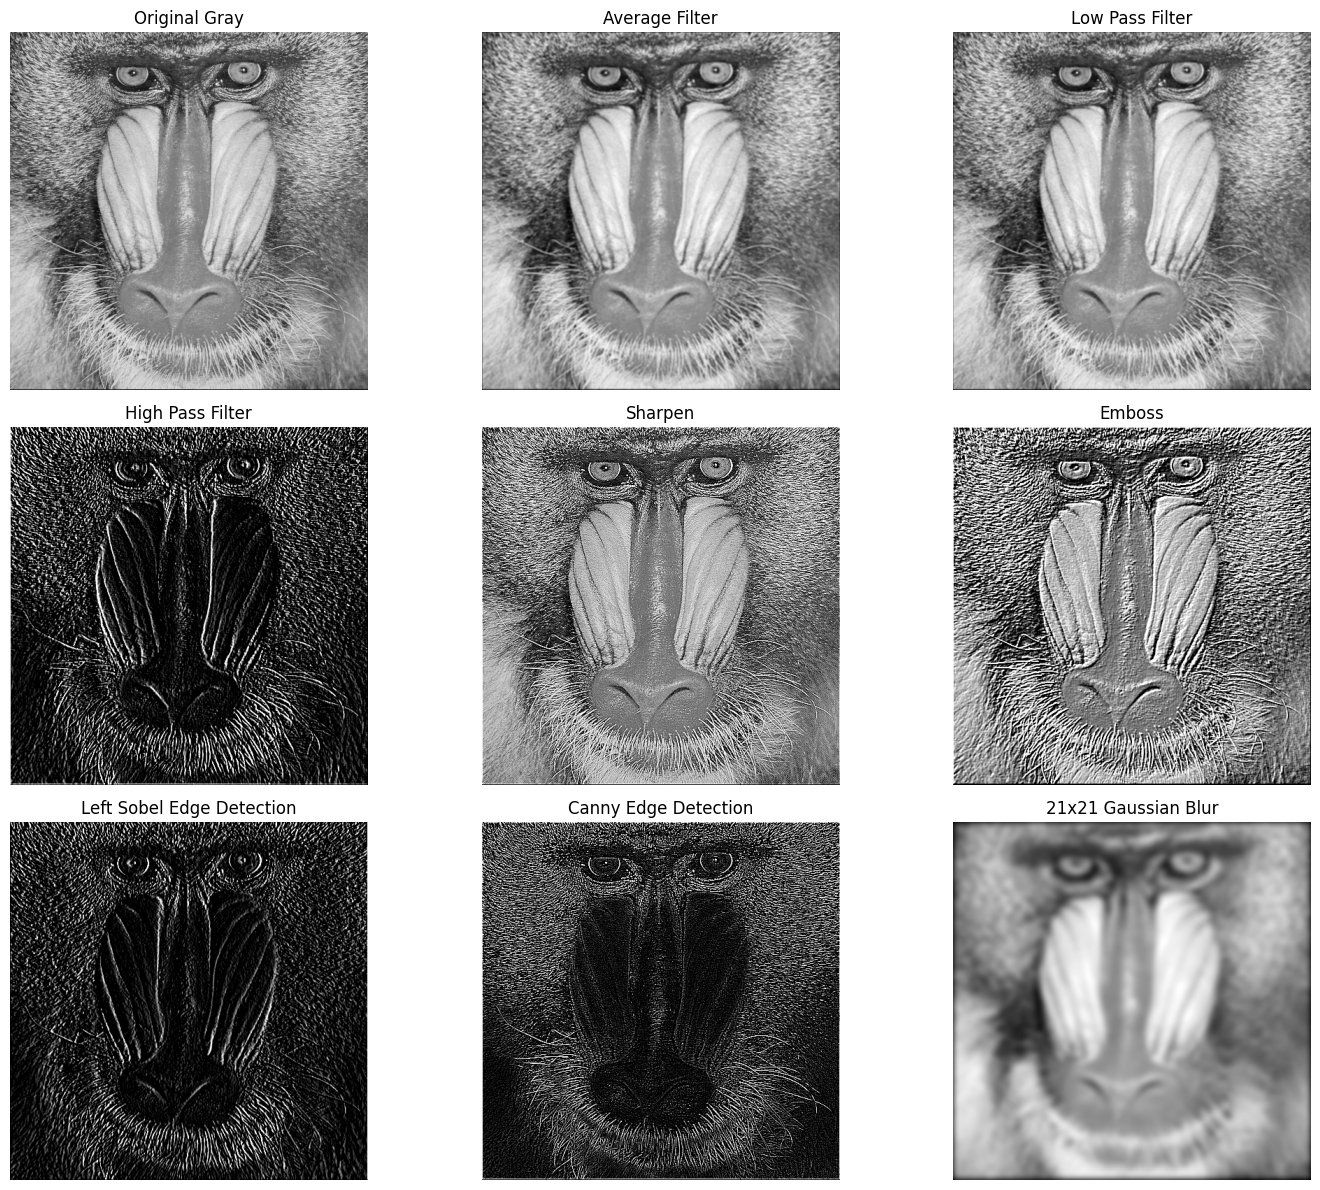

In [11]:
img_path = '/content/drive/MyDrive/PCVK_2026/mandrill.tiff'
img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Average Filter (3x3)
kernel_average = np.ones((3, 3), np.float32) / 9.0

# Low Pass Filter (3x3)
kernel_low_pass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], dtype=np.float32) / 12.0

# High Pass Filter (3x3)
kernel_high_pass = np.array([
    [-1, 0, 1],
    [-1, 0, 3],
    [-3, 0, 1]
], dtype=np.float32)

# Sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# Emboss
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
], dtype=np.float32)

# Left Sobel Edge Detection
kernel_left_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

# Canny Edge Detection
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21 = gaussian_1d @ gaussian_1d.transpose()

# Menjalankan fungsi konvolusi buatan
res_average   = convolution2d(img_gray, kernel_average, stride=1, padding=1)
res_low_pass  = convolution2d(img_gray, kernel_low_pass, stride=1, padding=1)
res_high_pass = convolution2d(img_gray, kernel_high_pass, stride=1, padding=1)
res_sharpen   = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss    = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_sobel     = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny     = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
res_gaussian  = convolution2d(img_gray, kernel_gaussian_21, stride=1, padding=10)

results = [
    ("Original Gray", img_gray),
    ("Average Filter", res_average),
    ("Low Pass Filter", res_low_pass),
    ("High Pass Filter", res_high_pass),
    ("Sharpen", res_sharpen),
    ("Emboss", res_emboss),
    ("Left Sobel Edge Detection", res_sobel),
    ("Canny Edge Detection", res_canny),
    ("21x21 Gaussian Blur", res_gaussian)
]

plt.figure(figsize=(15, 12))
for i, (title, img_res) in enumerate(results):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_res, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

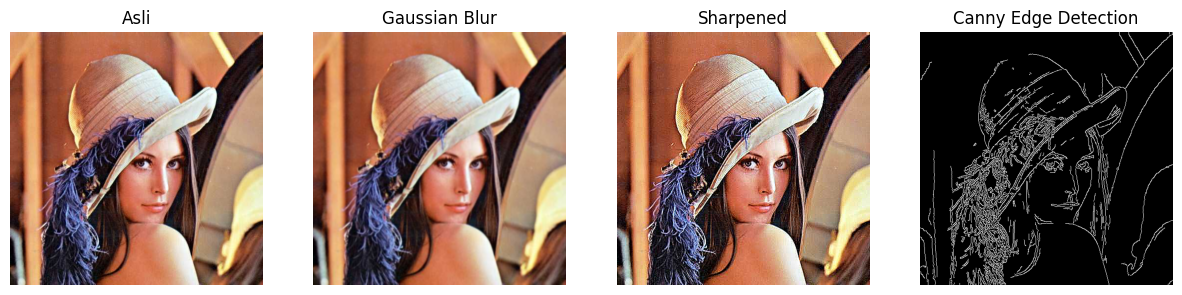

In [14]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK_2026/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])